# Technology Track Starter Notebook

## Global AI Adoption & Workforce Impact

### Research Question

**Can companies improve productivity through AI adoption without causing major workforce reductions, and does AI governance maturity change that relationship?**

This notebook is beginner-friendly and focuses on:

1. Loading and understanding the data
2. Exploring patterns with Seaborn visualizations
3. Building a simple baseline machine learning model
4. Interpreting findings clearly

## Setup

If needed, run the next cell to install required libraries in the notebook kernel.

In [9]:
# Uncomment and run if you are missing packages.
# %pip install seaborn scikit-learn kagglehub

In [10]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

## Download and Load Dataset

This uses KaggleHub to download the latest dataset files directly from Kaggle.

In [11]:
# Download latest version of the dataset
path = kagglehub.dataset_download(
    "mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset"
)
print("Path to dataset files:", path)

# Prefer ai_company_adoption.csv, otherwise use the first CSV found.
dataset_dir = Path(path)
preferred = list(dataset_dir.rglob("ai_company_adoption.csv"))
csv_files = preferred if preferred else list(dataset_dir.rglob("*.csv"))

if not csv_files:
    raise FileNotFoundError("No CSV files were found in the downloaded dataset directory.")

data_path = csv_files[0]
print("Using file:", data_path)

df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()

Path to dataset files: /home/odinroast/.cache/kagglehub/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset/versions/1
Using file: /home/odinroast/.cache/kagglehub/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset/versions/1/ai_company_adoption.csv
Shape: (150000, 43)


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,company_founding_year,company_age,company_age_group,ai_adoption_rate,ai_adoption_stage,years_using_ai,ai_primary_tool,num_ai_tools_used,ai_use_case,ai_projects_active,ai_training_hours,ai_budget_percentage,ai_maturity_score,ai_failure_rate,ai_investment_per_employee,regulatory_compliance_score,data_privacy_level,ai_ethics_committee,ai_risk_management_score,remote_work_percentage,employee_satisfaction_score,task_automation_rate,time_saved_per_week,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,30.57,pilot,3,ChatGPT,1,Customer Support,3,20.94,6.54,0.224,35.22,55392.29,60,Medium,No,60,14.55,6.95,19.47,6.44,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,27.25,pilot,4,ChatGPT,3,Software Development,0,23.10,5.81,0.174,24.65,49210.79,68,High,No,53,50.25,5.16,26.24,8.92,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,31.54,pilot,2,Custom Internal AI,3,HR Automation,3,12.29,12.39,0.266,36.51,105011.76,66,High,No,53,41.70,4.57,22.24,7.59,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,11.02,pilot,2,Custom Internal AI,1,Software Development,2,11.31,3.20,0.123,33.30,27157.71,64,High,No,44,28.10,5.33,2.87,3.16,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,1994,30,16-30 years,33.39,pilot,7,ChatGPT,3,Customer Support,5,35.17,9.98,0.363,19.83,84622.90,68,High,Yes,77,29.93,6.00,18.44,7.03,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation


## Quick Data Check

We will inspect column names, missing values, and data types before any analysis.

In [12]:
print("Total rows:", len(df))
print("Total columns:", len(df.columns))

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("\nTop columns by missing percentage:")
display(missing_pct.head(10).to_frame("missing_%"))

display(df.head(3))

Total rows: 150000
Total columns: 43

Top columns by missing percentage:


,missing_%
response_id,0.0
company_id,0.0
survey_year,0.0
quarter,0.0
country,0.0
region,0.0
industry,0.0
company_size,0.0
num_employees,0.0
annual_revenue_usd_millions,0.0


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,company_founding_year,company_age,company_age_group,ai_adoption_rate,ai_adoption_stage,years_using_ai,ai_primary_tool,num_ai_tools_used,ai_use_case,ai_projects_active,ai_training_hours,ai_budget_percentage,ai_maturity_score,ai_failure_rate,ai_investment_per_employee,regulatory_compliance_score,data_privacy_level,ai_ethics_committee,ai_risk_management_score,remote_work_percentage,employee_satisfaction_score,task_automation_rate,time_saved_per_week,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,30.57,pilot,3,ChatGPT,1,Customer Support,3,20.94,6.54,0.224,35.22,55392.29,60,Medium,No,60,14.55,6.95,19.47,6.44,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,27.25,pilot,4,ChatGPT,3,Software Development,0,23.10,5.81,0.174,24.65,49210.79,68,High,No,53,50.25,5.16,26.24,8.92,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,31.54,pilot,2,Custom Internal AI,3,HR Automation,3,12.29,12.39,0.266,36.51,105011.76,66,High,No,53,41.70,4.57,22.24,7.59,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation


## Select Columns for Analysis

Map dataset columns to our analysis framework.

In [13]:
# Direct column assignments
columns = {
    "productivity": "ai_adoption_rate",  # Our core outcome metric
    "adoption_stage": "ai_adoption_stage",
    "automation_rate": "num_ai_tools_used",  # Number of tools = automation scope
    "ai_investment": "annual_revenue_usd_millions",  # Revenue proxy for investment
    "governance": "ai_projects_active",  # Active projects = governance maturity
    "industry": "industry",
    "country": "country",
}

print("Selected columns for analysis:")
for key, value in columns.items():
    print(f"  {key:20s} => {value}")

Selected columns for analysis:
  productivity         => ai_adoption_rate
  adoption_stage       => ai_adoption_stage
  automation_rate      => num_ai_tools_used
  ai_investment        => annual_revenue_usd_millions
  governance           => ai_projects_active
  industry             => industry
  country              => country


## Exploratory Data Analysis (EDA)

**What is EDA?**
Exploratory Data Analysis means looking at your data visually before building any models. The goal is to understand patterns, spot unusual values, and get familiar with what the data is actually saying.

Think of it like reading a few chapters of a book before writing a report on it — you need to understand what you're working with first!

We'll create **three charts**, each answering a different question about AI adoption:

| Chart | Question |
|-------|----------|
| 1. Bar Chart | Does being further along the AI adoption journey mean higher adoption rates? |
| 2. Scatter Plot | Do companies that use more AI tools tend to have higher adoption rates? |
| 3. Histogram | What does the overall distribution of AI adoption rates look like? |

---
> **Tip:** Run each cell one at a time and read the explanation before moving to the next one.

---

### Chart 1: Average AI Adoption Rate by Adoption Stage

**What we're looking at:** Companies are often labeled by how far along they are in their AI journey — stages like "Exploring", "Implementing", or "Scaling". This chart shows the **average AI adoption rate** for companies at each stage.

**Why it matters:** If more advanced stages consistently show higher adoption rates, it tells us that progression through AI stages is meaningful — not just a label. It also suggests that where a company is in its journey is a useful predictor of adoption success.

**What to look for:**
- Are the bars clearly different in height? That suggests adoption stage really matters.
- Which stage has the highest average adoption rate?
- Is the order what you'd expect? (e.g., Scaling > Implementing > Exploring)
- Are there any surprising results?

> **Beginner tip:** A bar chart is great for comparing a number (like an average) across different categories. Taller bar = higher value for that group.

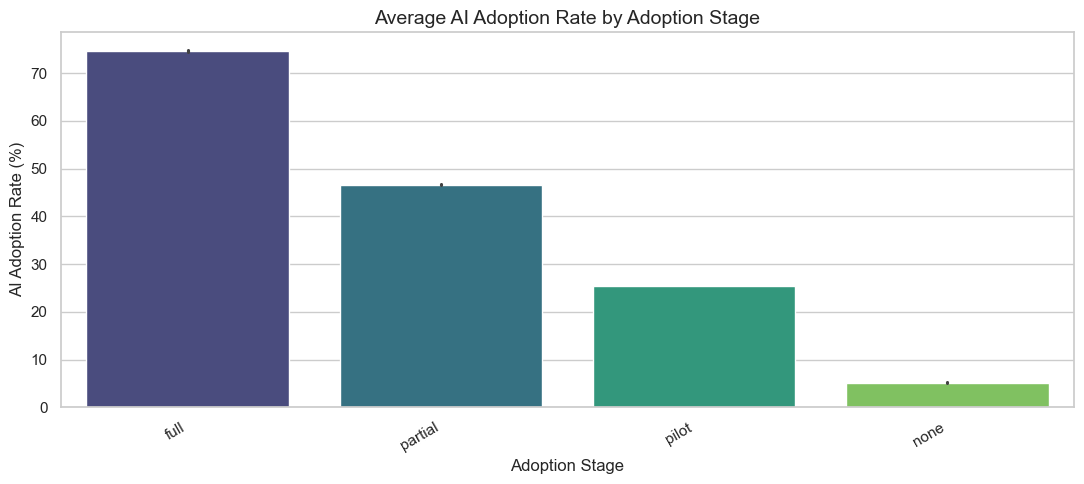

Average adoption rate per stage (sorted):
ai_adoption_stage
full       74.65
partial    46.64
pilot      25.42
none        5.14


In [14]:
# Chart 1: Average AI adoption rate by adoption stage
# -------------------------------------------------------
# We group ALL companies by their adoption stage, then calculate the mean (average)
# adoption rate for each group. sns.barplot draws one bar per stage.
# Stages are sorted from highest to lowest average for easy reading.

plt.figure(figsize=(11, 5))

stage_order = (
    df.groupby(columns["adoption_stage"])[columns["productivity"]]
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.barplot(
    data=df,
    x=columns["adoption_stage"],
    y=columns["productivity"],
    order=stage_order,
    palette="viridis",
)

plt.title("Average AI Adoption Rate by Adoption Stage", fontsize=14)
plt.ylabel("AI Adoption Rate (%)")
plt.xlabel("Adoption Stage")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Print the numbers behind the chart for extra context
print("Average adoption rate per stage (sorted):")
print(
    df.groupby(columns["adoption_stage"])[columns["productivity"]]
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .to_string()
)

---

### Chart 2: AI Tools Used vs. AI Adoption Rate by Industry

**What we're looking at:** Each dot in this chart represents **one company**. Its position on the x-axis shows how many AI tools it uses, and its position on the y-axis shows its AI adoption rate. Dots are colored by industry so you can spot industry-level patterns.

**Why it matters:** Using more AI tools might signal a deeper commitment to AI — which could drive higher adoption rates. Or, companies that are already highly committed to AI naturally end up using more tools. Either way, a relationship here is worth investigating!

**What to look for:**
- Is there a general upward trend? (More tools → higher adoption rate?)
- Do certain industries cluster toward the top-right (high tools, high adoption)?
- Do any industries stand out as outliers?

> **Beginner tip:** A scatter plot is used to see if two numeric variables are related. Each point is a single observation (here, a company). A diagonal pattern of dots suggests a relationship between the two variables.

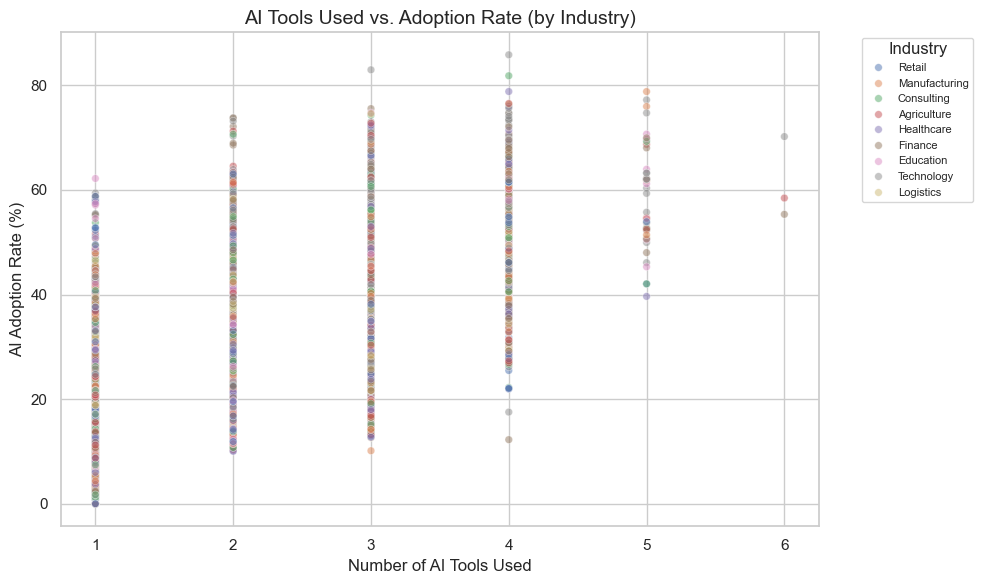

Pearson correlation (tools used vs. adoption rate): 0.539
(Values near 1 or -1 = strong relationship; near 0 = weak relationship)


In [15]:
# Chart 2: AI tools used vs. adoption rate, colored by industry
# ---------------------------------------------------------------
# We take a random sample of up to 5,000 companies so the chart isn't too crowded.
# Each dot is one company — its x position shows how many AI tools it uses,
# and its y position shows its adoption rate. The color shows which industry it's in.

sample = df.sample(min(5000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample,
    x=columns["automation_rate"],
    y=columns["productivity"],
    hue=columns["industry"],
    alpha=0.5,
    s=30,
)

plt.title("AI Tools Used vs. Adoption Rate (by Industry)", fontsize=14)
plt.xlabel("Number of AI Tools Used")
plt.ylabel("AI Adoption Rate (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, title="Industry")
plt.tight_layout()
plt.show()

# Quick correlation check: are tools used and adoption rate related?
corr = df[[columns["automation_rate"], columns["productivity"]]].corr().iloc[0, 1]
print(f"Pearson correlation (tools used vs. adoption rate): {corr:.3f}")
print("(Values near 1 or -1 = strong relationship; near 0 = weak relationship)")

### Chart 3: Distribution of AI Adoption Rates

**What we're looking at:** This histogram shows how AI adoption rates are spread across **all companies** in the dataset. Each bar covers a range of adoption rates and its height tells you how many companies fall in that range. The smooth curve on top (called a KDE) is a smoothed version of the same pattern.

**Why it matters:** Understanding the distribution helps us set expectations. Is the data spread evenly? Is there a "typical" adoption rate? Are many companies clustered at the low end, or are they spread across the full range?

**What to look for:**
- Is the distribution roughly bell-shaped (normal), or does it lean to one side?
- Where is the peak? That's the most common adoption rate range in the dataset.
- Are there many companies at the extremes (very high or very low)?

> **Beginner tip:** A histogram groups continuous values into ranges (called "bins") and counts how many data points fall in each one. It's one of the most useful charts for understanding a variable at a glance.

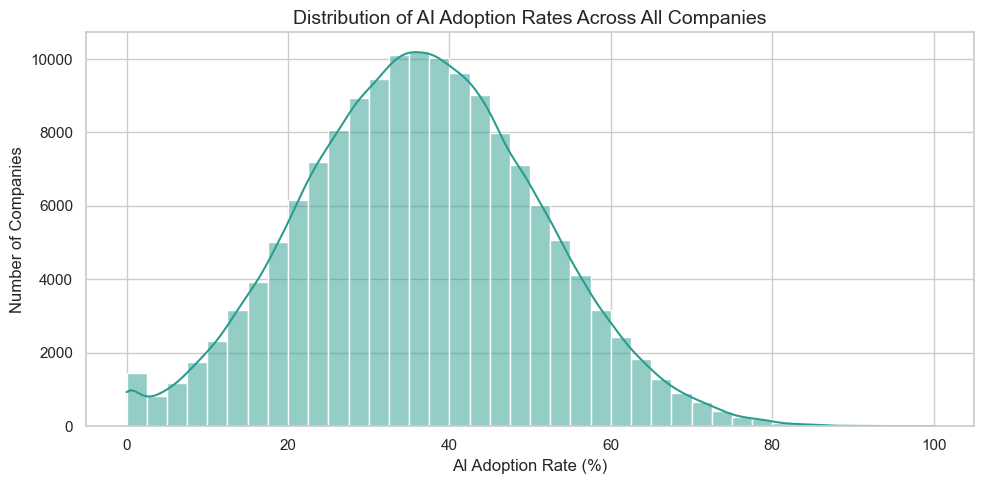

Summary statistics for AI Adoption Rate:
count    150000.00
mean         36.41
std          14.54
min           0.00
25%          26.43
50%          36.32
75%          46.20
max         100.00
Name: ai_adoption_rate, dtype: float64


In [16]:
# Chart 3: Distribution of AI adoption rates
# -------------------------------------------
# A histogram shows how often each range of adoption rates appears in the dataset.
# kde=True adds a smooth curve on top, making trends easier to see.
# bins=40 means the range is divided into 40 equal-width buckets.

plt.figure(figsize=(10, 5))

sns.histplot(data=df, x=columns["productivity"], bins=40, kde=True, color="#2a9d8f")

plt.title("Distribution of AI Adoption Rates Across All Companies", fontsize=14)
plt.xlabel("AI Adoption Rate (%)")
plt.ylabel("Number of Companies")
plt.tight_layout()
plt.show()

# Summary statistics for context
print("Summary statistics for AI Adoption Rate:")
print(df[columns["productivity"]].describe().round(2))

## Baseline Machine Learning Model

Goal: predict productivity using AI adoption, automation, governance, and company context.

This is a baseline model, not a final production model.

In [17]:
# Prepare data for modeling
target_col = columns["productivity"]

candidate_features = [
    columns["adoption_stage"],
    columns["automation_rate"],
    columns["ai_investment"],
    columns["governance"],
    columns["industry"],
    columns["country"],
]
feature_cols = [c for c in candidate_features if c is not None and c != target_col]

model_df = df[feature_cols + [target_col]].copy()
model_df[target_col] = pd.to_numeric(model_df[target_col], errors="coerce")
model_df = model_df.dropna(subset=[target_col])

# Keep row count manageable for quick notebook runs.
if len(model_df) > 50000:
    model_df = model_df.sample(50000, random_state=42)

X = model_df[feature_cols]
y = model_df[target_col]

num_features = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
cat_features = [c for c in X.columns if c not in num_features]

numeric_pipeline = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_features),
        ("cat", categorical_pipeline, cat_features),
    ]
)

model = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    random_state=42,
    n_jobs=-1,
)

pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", model),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"Rows used for modeling: {len(model_df):,}")
print(f"Features used: {feature_cols}")
print(f"MAE: {mae:.4f}")
print(f"R^2: {r2:.4f}")

Rows used for modeling: 50,000
Features used: ['ai_adoption_stage', 'num_ai_tools_used', 'annual_revenue_usd_millions', 'ai_projects_active', 'industry', 'country']
MAE: 5.3610
R^2: 0.7974


## How to Use This Model in Practice

### Your Model Does This:

The Random Forest model learns patterns from company data to predict **AI adoption rate** based on:

1. **AI adoption stage** (e.g., Exploring, Implementing, Scaling)
2. **Number of AI tools used** (automation scope)
3. **Annual revenue** (company size / investment capacity)
4. **Active AI projects** (governance maturity)
5. **Industry** (e.g., Tech, Finance, Healthcare)
6. **Country** (regional factors)

### How Your Team Should Use It:

**Scenario 1: Predict adoption for a new company**
- Collect data on a company's adoption stage, tools, revenue, etc.
- Feed it into the trained model: `pipeline.predict(new_company_data)`
- The model returns an **expected AI adoption rate**.
- If real adoption is much lower, ask: *Why is this company underperforming?*
- If real adoption is higher, ask: *What are they doing right?*

**Scenario 2: Identify key drivers of adoption**
- Check model feature importance (which inputs matter most).
- Use EDA and the model together to tell a story:
  - "Companies in the Scaling stage achieve X% adoption"
  - "Companies using Y tools see Z% higher adoption"

### Key Limitations (Always Mention These!):

- The model assumes patterns from historical data hold in the future.
- **Correlation ≠ Causation**: High adoption stage correlates with high adoption rate, but that doesn't mean one causes the other.
- Outliers (unusual companies) may not be predicted well.
- Regional, industry, and time-based shifts can break the model.

### Your Presentation Story:

1. **Question**: Can we predict which companies will have high AI adoption?
2. **Data**: Used 150K+ company observations across industries & countries.
3. **EDA**: Found that adoption stage, tools, and governance correlate with adoption rates.
4. **Model**: Built a Random Forest to capture these patterns (R² = ?).
5. **Evidence**: Show predictions vs reality, feature importance plots, and errors.
6. **Conclusion**: Adoption stage and governance maturity are strong signals; consider [your insight].
7. **Limits**: Acknowledge correlation/causation, data bias, and future unknowns.